In [1]:
from ultralytics import YOLO
import torch

In [3]:
import inspect

In [ ]:
model = YOLO("yolo11n.pt")

In [8]:
results = model.train(
    data="../data/raw/yolo/data.yaml",
    epochs=200,
    imgsz=640,
    device=0,
    name="train"
    )


New https://pypi.org/project/ultralytics/8.3.205 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.203 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train6, nbs=64, nms=Fals

In [9]:
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map  # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps  # a list contains map50-95 of each category

Ultralytics 8.3.203 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1407.7±830.9 MB/s, size: 1375.6 KB)
val: Scanning /home/jcibeira/INA/cell_classifier_yolo/data/raw/yolo/validation/labels.cache... 26 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 26/26 56.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 0.8it/s 2.6s4.3s
                   all         26        359      0.551      0.595      0.574      0.391
            interphase         10        259      0.644      0.672      0.695      0.513
             metaphase         21         34      0.726      0.706      0.747      0.444
             telophase         11         27      0.509      0.346      0.344      0.215
              anaphase         11         22      0.639      0.545      0.72

array([    0.51275,     0.44438,     0.21456,     0.53496,     0.24755])


image 1/1 /home/jcibeira/INA/cell_classifier_yolo/notebooks/../data/raw/yolo/test/images/---------Mitotic-cell-division-stages-of-Allium-cepa-L--019_jpg.rf.b88aef91a0fb150b57d22b44dcd17933.jpg: 640x640 2 metaphases, 2 telophases, 46.9ms
Speed: 11.2ms preprocess, 46.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


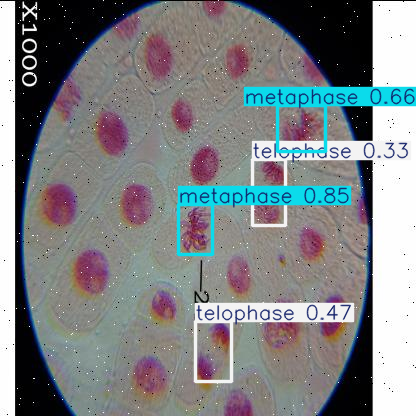

In [14]:
results = model("../data/raw/yolo/test/images/---------Mitotic-cell-division-stages-of-Allium-cepa-L--019_jpg.rf.b88aef91a0fb150b57d22b44dcd17933.jpg")
results[0].show()

In [1]:
from cell_classifier.utils.plot_yolo_annotations import plot_yolo_annotations

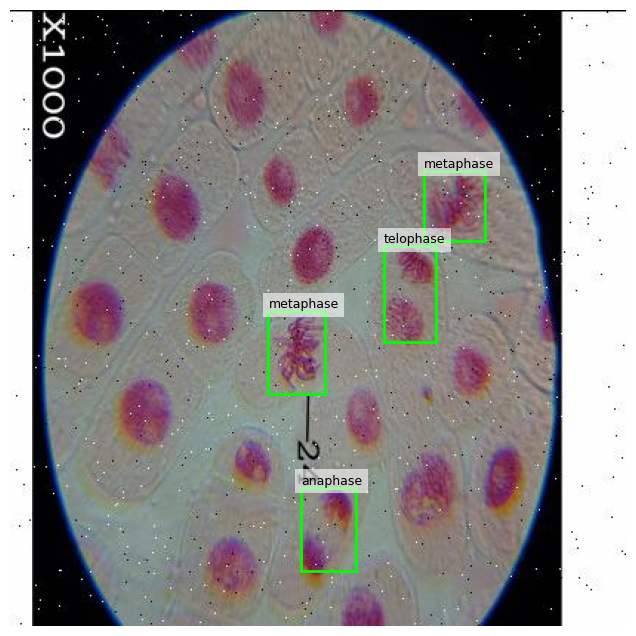

In [2]:
plot_yolo_annotations("../data/raw/yolo/test/images/---------Mitotic-cell-division-stages-of-Allium-cepa-L--019_jpg.rf.b88aef91a0fb150b57d22b44dcd17933.jpg",
                      class_names=["interphase","metaphase","telophase","anaphase","prophase"])
